Libraries Required

In [ ]:

# Import Required Libraries


# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

LOADING DATASET

In [6]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")


DATASET STRUCTURE

In [7]:
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


MISSING VALUES AND NULL VALUES - NONE

In [39]:
df.isnull().sum()
df.dropna(inplace=True)



In [10]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

Removing unnecessary columns for accuracy - "customerID"

In [11]:
df.drop("customerID", axis=1, inplace=True)

FIXING DATA TYPES- "TotalCharges" - was: object, is: float64

In [67]:
df.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [66]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"], errors="coerce")

#fixed data type

#check again
df.isnull().sum()
df.dropna(inplace=True)
df.duplicated().sum()
df.drop_duplicates(inplace=True)

Check categorical values - everything ok

In [65]:
for col in df.select_dtypes(include="object").columns:
    print(col)
    print(df[col].unique())
    print("-"*50)

Check Class imbalance - "moderately imbalanced"

In [63]:
df["Churn"].value_counts()

Churn
0    5153
1    1857
Name: count, dtype: int64

In [62]:
df["Churn"].value_counts(normalize=True)*100
# moderately imbalanced

Churn
0    73.509272
1    26.490728
Name: proportion, dtype: float64

EDA - Exploratory data analysis
->Who is more likely to churn?
->features vs target

1. churn distribution


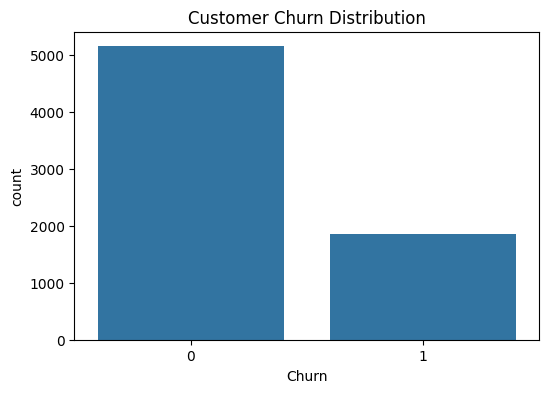

In [61]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()

2. gender vs churn

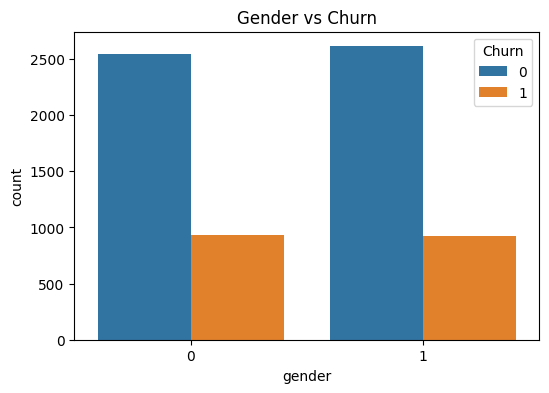

In [59]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df)

plt.title("Gender vs Churn")
plt.show()

senior citizen vs churn

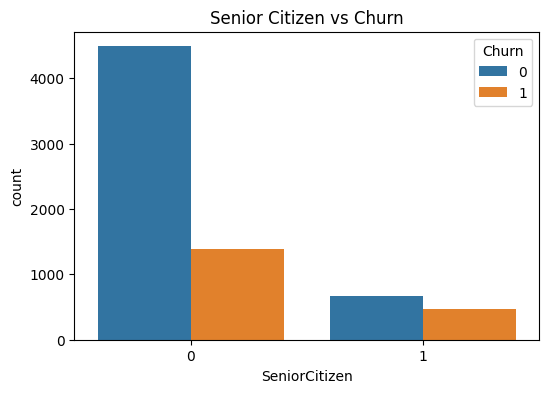

In [58]:
plt.figure(figsize=(6,4))
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)

plt.title("Senior Citizen vs Churn")
plt.show()

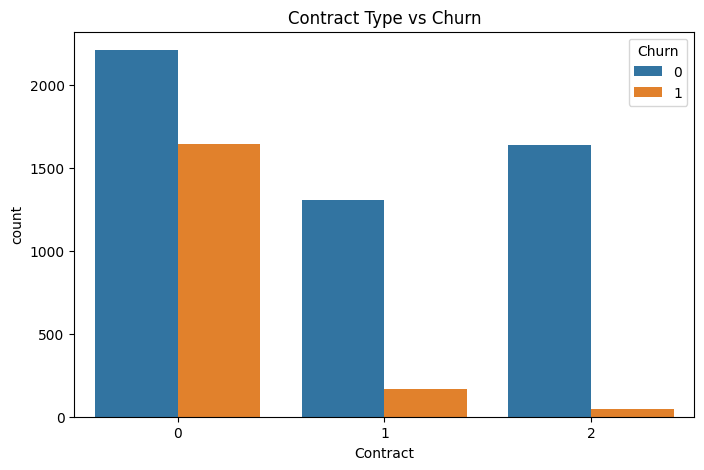

In [57]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Contract Type vs Churn")
plt.show()

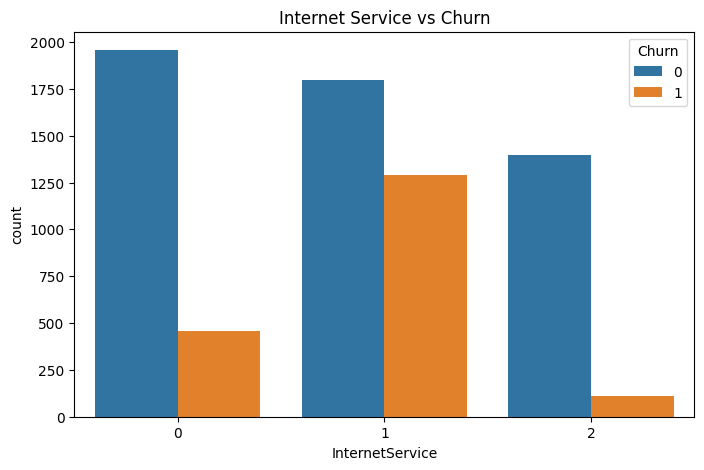

In [56]:
plt.figure(figsize=(8,5))
sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Internet Service vs Churn")
plt.show()

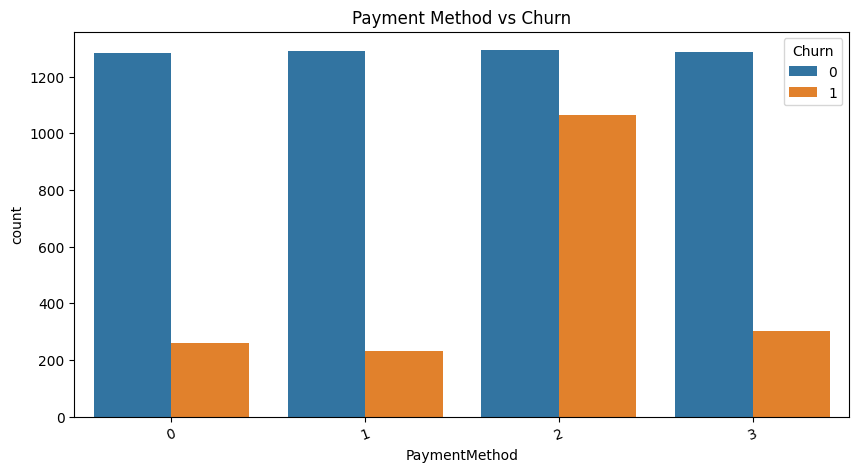

In [55]:
plt.figure(figsize=(10,5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.xticks(rotation=20)
plt.title("Payment Method vs Churn")
plt.show()

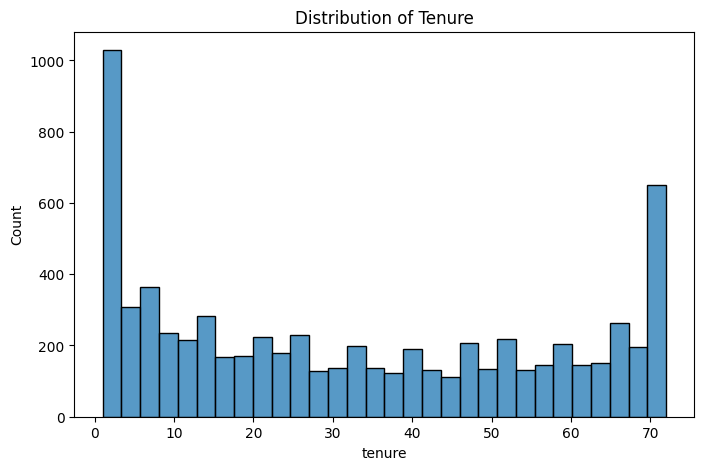

In [54]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30)

plt.title("Distribution of Tenure")
plt.show()

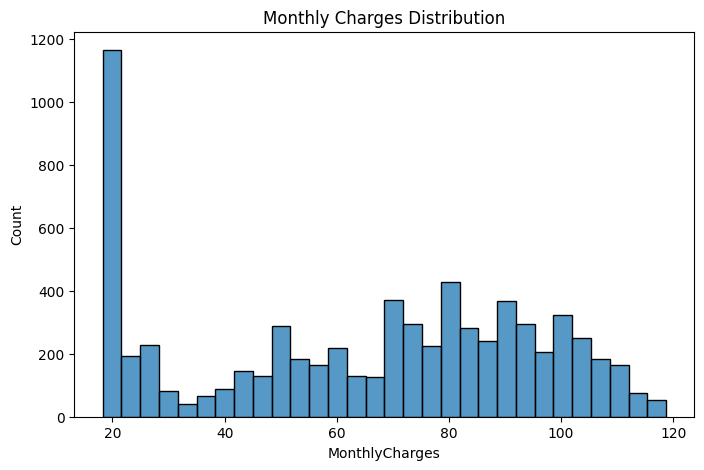

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30)

plt.title("Monthly Charges Distribution")
plt.show()

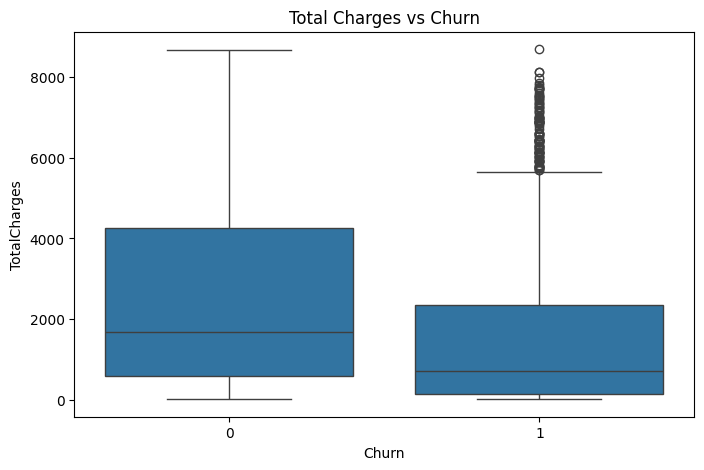

In [52]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="TotalCharges", data=df)

plt.title("Total Charges vs Churn")
plt.show()

->Feature Engineering

This is where we prepare the data for machine learning.

Encode all categorical columns. - LableEncoder
Separate features (X) and target (y).
Perform the train-test split.
Train Logistic Regression, Decision Tree, and Random Forest.
Compare all three models.
Tune the best one (Random Forest) using GridSearchCV.
Evaluate with Accuracy, Precision, Recall, F1-score, ROC-AUC, and a Confusion Matrix.
Plot Feature Importance.
Save the best model as a .pkl file

In [51]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   int64  
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   int64  
 3   Dependents        7010 non-null   int64  
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   int64  
 6   MultipleLines     7010 non-null   int64  
 7   InternetService   7010 non-null   int64  
 8   OnlineSecurity    7010 non-null   int64  
 9   OnlineBackup      7010 non-null   int64  
 10  DeviceProtection  7010 non-null   int64  
 11  TechSupport       7010 non-null   int64  
 12  StreamingTV       7010 non-null   int64  
 13  StreamingMovies   7010 non-null   int64  
 14  Contract          7010 non-null   int64  
 15  PaperlessBilling  7010 non-null   int64  
 16  PaymentMethod     7010 non-null   int64  
 17  

relationships through heatmap

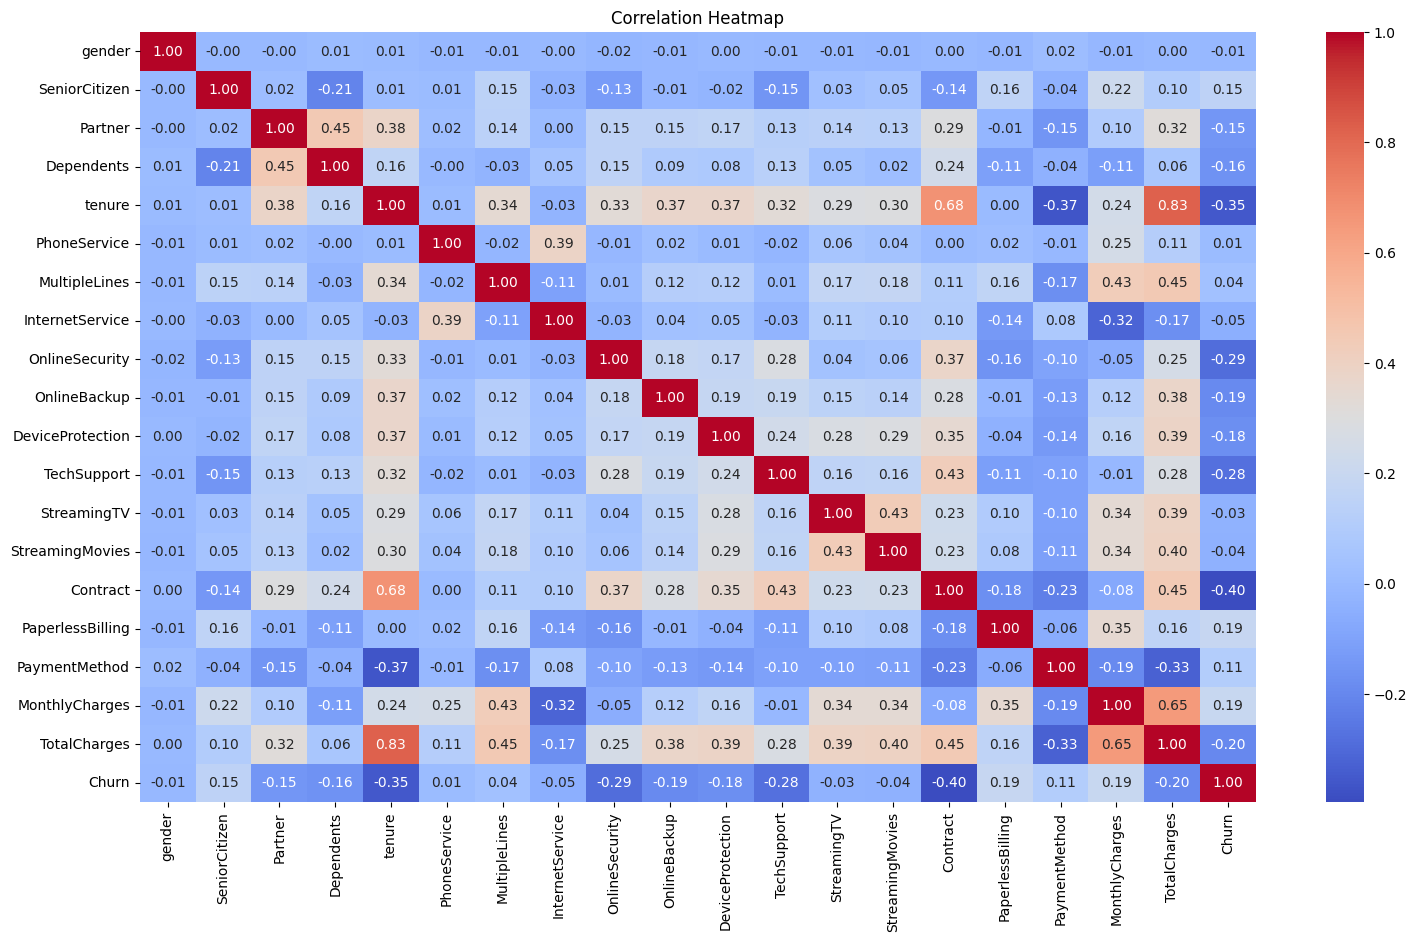

In [50]:
plt.figure(figsize=(18,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Features (X)- All except churn vs Target (y) - Churn

In [68]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
print(X.shape)
print(y.shape)

(7010, 19)
(7010,)


MACHINE LEARNING - 
1. TRAIN_TEST_SPLIT - 80 TRAIN, 20 TEST
2. MODELS - Logistic Regression, Decision Tree, Random Forest

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print(X_train.shape)  
print(X_test.shape)

(5608, 19)
(1402, 19)


In [70]:
X.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [71]:
X_train.isnull().sum().sum()

np.int64(0)

LOGISTIC REGRESSION - 82%
DECISION TREE
RANDOM FOREST

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [75]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

LOGISTIC REGRESSION

In [77]:
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))

Accuracy: 0.8216833095577746
Precision: 0.6179401993355482
Recall: 0.5794392523364486
F1 Score: 0.5980707395498392


DECISION TREE

In [78]:
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))

Accuracy: 0.7353780313837375
Precision: 0.4381188118811881
Recall: 0.5514018691588785
F1 Score: 0.4882758620689655


RANDOM FOREST

In [79]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

Accuracy: 0.8009985734664765
Precision: 0.5734265734265734
Recall: 0.5109034267912772
F1 Score: 0.5403624382207578


CONFUSION MATRIX

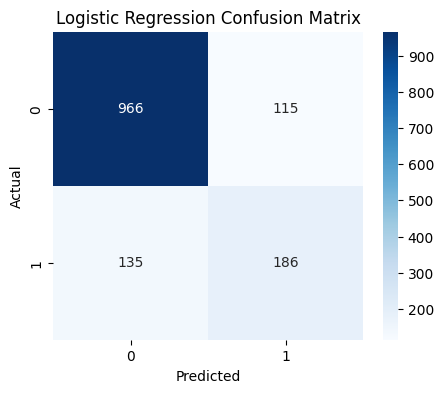

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

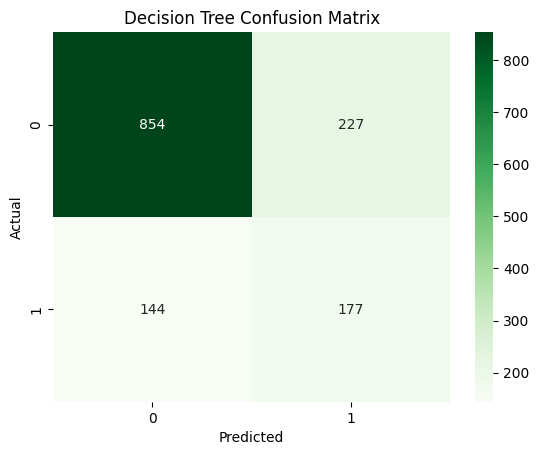

In [81]:
cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

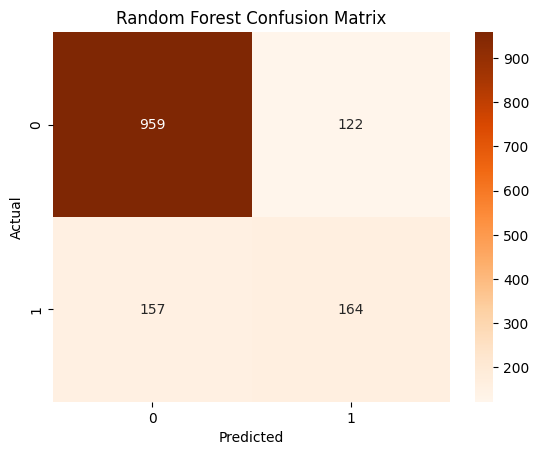

In [82]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

CLASSIFICATION REPORT FOR LOGISTIC REGRESSION

In [83]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1081
           1       0.62      0.58      0.60       321

    accuracy                           0.82      1402
   macro avg       0.75      0.74      0.74      1402
weighted avg       0.82      0.82      0.82      1402



HYPER PARAMETER TUNING IMPROVES ACCURACY FOR RANDOM FOREST

In [84]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

rf_tuned_pred = rf_tuned.predict(X_test)

In [85]:
print("Accuracy:", accuracy_score(y_test, rf_tuned_pred))
print("Precision:", precision_score(y_test, rf_tuned_pred))
print("Recall:", recall_score(y_test, rf_tuned_pred))
print("F1 Score:", f1_score(y_test, rf_tuned_pred))

Accuracy: 0.8174037089871612
Precision: 0.6140350877192983
Recall: 0.5451713395638629
F1 Score: 0.5775577557755776


FEATURE IMPORTANCE 

In [86]:
importance = pd.Series(
    rf_tuned.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

tenure              0.162295
TotalCharges        0.149403
Contract            0.142988
MonthlyCharges      0.133007
OnlineSecurity      0.078558
TechSupport         0.059628
InternetService     0.042844
PaymentMethod       0.040919
OnlineBackup        0.029944
PaperlessBilling    0.024127
DeviceProtection    0.023069
MultipleLines       0.018904
SeniorCitizen       0.016359
Dependents          0.016238
gender              0.015591
Partner             0.013990
StreamingTV         0.013608
StreamingMovies     0.013276
PhoneService        0.005252
dtype: float64

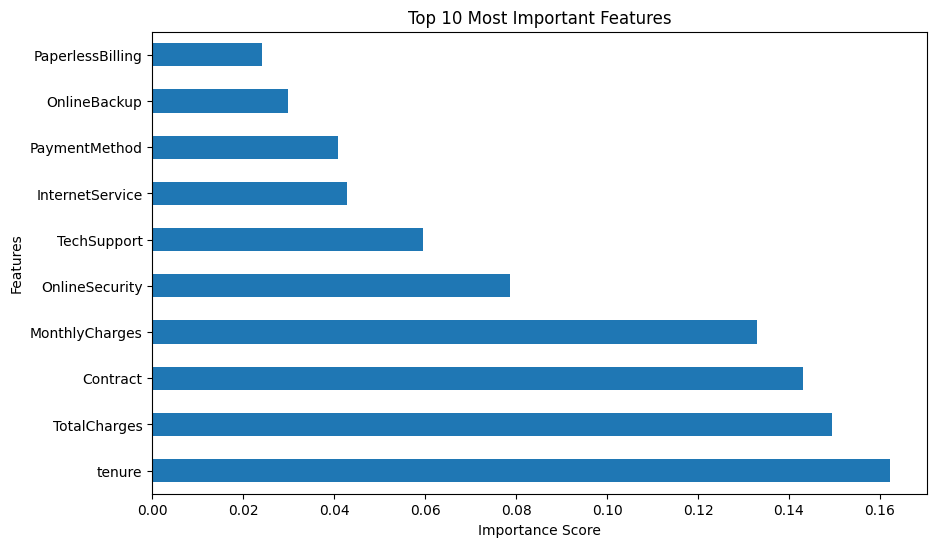

In [87]:
plt.figure(figsize=(10,6))

importance.head(10).plot(kind="barh")

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

SAVING BEST MODEL - LOGISTIC REGRESSION 

In [88]:
import joblib

joblib.dump(lr, "../models/churn_prediction_model.pkl")

['../models/churn_prediction_model.pkl']

In [89]:
sample = X_test.iloc[[0]]

prediction = lr.predict(sample)

print("Prediction:", prediction)
print("Actual:", y_test.iloc[0])

Prediction: [0]
Actual: 0


FINAL MODEL COMPARISION TABLE 
LOGISTIC REGRESSION TOP MOST ACCURACY.

In [91]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Random Forest Tuned"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, rf_tuned_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, rf_tuned_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, rf_tuned_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, rf_tuned_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.821683,0.617940,0.579439,0.598071
3,Random Forest Tuned,0.817404,0.614035,0.545171,0.577558
2,Random Forest,0.800999,0.573427,0.510903,0.540362
1,Decision Tree,0.735378,0.438119,0.551402,0.488276


# Conclusion

This project predicts customer churn using machine learning.

Four models were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- Tuned Random Forest

Logistic Regression achieved the highest accuracy (82.17%) and the best overall precision, recall, and F1-score.

Therefore, Logistic Regression was selected as the final model for deployment.

SAVING PROCESSED DATA

In [92]:
df.to_csv("../data/processed/clean_telco_churn.csv", index=False)